Draft

In [18]:

# data class Context
    # parameters
    # q(t) = 0vec
    # time # the init time the context is observed

# enum Part of Trajectory
    # ACCELERATION
    # CONSTANT
    # DECELERATION

# class TrapzoidTraject :
    # init (freq = 25 Hz)
    # setParameters(s_goal: vector, v_const: float, a: float)
    # getFullTrajectory() -> list of [A(t), partoftraject] until the end 
    # getTrajectoryAtTime(t) -> [A(t), partoftraject]

# class DatasetGenerator :
    # define context data min max range

    # generateDataset(n_contexts=1000, n_windows=50) -> list of [Context, Trajectory]
        # sampling combinations of Context and store in array        
        # for each context in n_contexts:
            # sampling window (init time of 50 points window) for n_windows times
            # generate full trajectory for the context
            # for each window:
                # store the context and the trajectory in the dataset



## Defining Class

In [19]:
import numpy as np
from scipy.spatial.transform import Rotation as R
import pandas as pd
from enum import Enum
from dataclasses import dataclass
from typing import List, Tuple
from tqdm import tqdm

class TrajectPart(Enum):
    ACCELERATION = 0
    CONSTANT = 1
    DECELERATION = 2

@dataclass
class Context:
    s_goal: np.ndarray  # Goal position (3d vector)
    v_const: float
    a: float
    q_init: np.ndarray = None  # Current pose at window start
    time_init: float = 0  # place holder
    part: TrajectPart = TrajectPart.CONSTANT  # place holder

'''
The 7d pose vector is represented as [x, y, z, quatw, quatx, quaty, quatz]
'''

'\nThe 7d pose vector is represented as [x, y, z, quatw, quatx, quaty, quatz]\n'

### Trajectory Engine

In [20]:

class TrapezoidTraject:
    def __init__(self, freq: int = 25):
        # Timing constants
        self.dt = 1.0 / freq
        
        # User-defined parameters
        self.v_const = 0.0
        self.a = 0.0
        
        # 3D Vector targets
        self.target_vec = np.zeros(3)
        self.unit_vec = np.zeros(3)
        self.total_dist = 0.0
        
        self.quaternion = np.array([1.0, 0.0, 0.0, 0.0])
        
        # 1D Path Phase Durations
        self.t_acc = 0.0
        self.t_const = 0.0
        self.t_total = 0.0
        
        # 1D Displacement checkpoints
        self.s_acc_dist = 0.0
        self.s_const_dist = 0.0
        
        # Triangle profile specific
        self.v_peak = 0.0

    def set_parameters(self, s_goal: np.ndarray, v_const: float, a: float):
        """
        Calculates the trapezoidal velocity profile projected onto a 3D vector.
        """
        self.v_const = v_const
        self.a = a
        self.target_vec = np.array(s_goal, dtype=np.float64)
        self.total_dist = np.linalg.norm(self.target_vec)
        
        # Handle zero-distance edge case
        if self.total_dist > 1e-9:
            self.unit_vec = self.target_vec / self.total_dist
            # Calculate Yaw: angle from X-axis towards the goal
            yaw = np.arctan2(self.target_vec[1], self.target_vec[0])
            rot = R.from_euler('z', yaw)
            quat_xyzw = rot.as_quat() 
            self.quaternion = np.array([quat_xyzw[3], quat_xyzw[0], quat_xyzw[1], quat_xyzw[2]])
        else:
            self.unit_vec = np.zeros(3)
            self.total_dist = 0.0
            self.quaternion = np.array([1.0, 0.0, 0.0, 0.0])

        # Initial 1D calculation
        self.t_acc = self.v_const / self.a
        self.s_acc_dist = 0.5 * self.a * (self.t_acc**2)
        
        if 2 * self.s_acc_dist > self.total_dist:
            # Triangle profile: Target distance is too short to reach v_const
            self.v_peak = np.sqrt(self.total_dist * self.a)
            self.t_acc = self.v_peak / self.a
            self.t_const = 0.0
            self.t_total = 2 * self.t_acc
            self.s_acc_dist = 0.5 * self.a * (self.t_acc**2)
            self.s_const_dist = 0.0
        else:
            # Standard Trapezoid profile
            self.s_const_dist = self.total_dist - (2 * self.s_acc_dist)
            self.t_const = self.s_const_dist / self.v_const
            self.t_total = (2 * self.t_acc) + self.t_const

    def set_parameters_by_context(self, context: Context):
        self.set_parameters(context.s_goal, context.v_const, context.a)

    def get_trajectory_at_time(self, t: float) -> Tuple[np.ndarray, TrajectPart]:
        if t <= 0:
            pos_scalar = 0.0
            part = TrajectPart.ACCELERATION
        elif t < self.t_acc:
            pos_scalar = 0.5 * self.a * (t**2)
            part = TrajectPart.ACCELERATION
        elif t < (self.t_acc + self.t_const):
            t_mid = t - self.t_acc
            pos_scalar = self.s_acc_dist + (self.v_const * t_mid)
            part = TrajectPart.CONSTANT
        elif t <= self.t_total:
            t_dec = t - (self.t_acc + self.t_const)
            pos_scalar = (self.total_dist - self.s_acc_dist) + \
                         (self.v_const * t_dec - 0.5 * self.a * (t_dec**2))
            part = TrajectPart.DECELERATION
        else:
            pos_scalar = self.total_dist
            part = TrajectPart.DECELERATION
        
        pos_vec = pos_scalar * self.unit_vec

        pose = np.concatenate([pos_vec, self.quaternion])
        return pose, part

    def get_trajectory_window(self, t_start: float, window_size: int) -> np.ndarray:
        """Returns a (window_size, 7) """
        trajectory_segment = np.zeros((window_size, 7))
        for step in range(window_size):
            t_current = t_start + (step * self.dt)
            pose, _ = self.get_trajectory_at_time(t_current)
            trajectory_segment[step] = pose
        return trajectory_segment

### Dataset Generator Class

In [10]:

import numpy as np
import pandas as pd
from tqdm import tqdm
from typing import List

class DatasetGenerator:
    def __init__(self):
        # Range definitions for 3D space
        # We sample a random distance and a random direction to create s_goal
        self.range_dist = [1.0, 5.0]  # magnitude in meters
        self.range_v = [0.1, 0.2]     # m/s
        self.range_a = [0.02, 0.04]   # m/s^2

        self.sample_contexts: List[Context] = []
        self.dataset = None

    def _generate_random_3d_goal(self) -> np.ndarray:
        """Generates a random 3D vector in a 2D circle plane, magnitude within range_dist."""
        # 1. Uniformly sample the angle (0 to 2pi)
        theta = np.random.uniform(0, 2 * np.pi)
        
        # 2. Uniformly sample the AREA, then find the radius
        r_min, r_max = self.range_dist
        dist2 = np.random.uniform(r_min**2, r_max**2)
        dist = np.sqrt(dist2)
        
        # 3. Convert Polar to Cartesian (XY Plane)
        return np.array([
            dist * np.cos(theta),
            dist * np.sin(theta),
            0.0
        ])
    
    def _generate_random_context(self) -> Context:
        s_g_vec = self._generate_random_3d_goal()
        v_c = np.random.uniform(*self.range_v)
        acc = np.random.uniform(*self.range_a)
        return Context(s_goal=s_g_vec, v_const=v_c, a=acc)

    def generate_dataset(self, n_contexts=2000, n_windows=50, window_size=50):
        traject_gen = TrapezoidTraject(freq=25)

        features_list = []
        targets_list = []

        # Generate context samples first
        self.sample_contexts = [self._generate_random_context() for _ in range(n_contexts)]

        for context in tqdm(self.sample_contexts, desc="Generating Trajectories"):
            
            # Temporary context to set parameters
            traject_gen.set_parameters_by_context(context)
            
            # Sample random window start times
            total_time = traject_gen.t_total
            start_times = np.random.uniform(0, total_time, n_windows) # the window may starts even at the end

            for t_start in start_times:
                # 1. Capture 3D state at t_start
                q_init_vec, part_init = traject_gen.get_trajectory_at_time(t_start)
                
                # 2. Capture the 50-step 3D trajectory segment (Shape: 50, 3)
                trajectory_segment = traject_gen.get_trajectory_window(t_start, window_size)

                # Feature Vector, Shape: (10,)
                feat = np.array([
                    *context.s_goal, context.v_const, context.a,
                    *q_init_vec, t_start, part_init.value
                ], dtype=np.float16)
                features_list.append(feat)
                
                # Target Tensor (3D Trajectory), Shape: (window_size, 3)
                targets_list.append(trajectory_segment.astype(np.float16))

        # Convert lists to high-dimensional numpy arrays
        features = np.array(features_list)      # Shape: (N, 10)
        targets = np.array(targets_list)        # Shape: (N, 50, 3) <--- 3D preserved!
        
        feature_col_names = np.array([
            's_goal_x', 's_goal_y', 's_goal_z', 
            'v_const', 'accel', 
            'q_init_x', 'q_init_y', 'q_init_z', 
            'q_init_quatw', 'q_init_quatx', 'q_init_quaty', 'q_init_quatz',
            't_init', 'part_enum'
        ])

        self.dataset = {
            'features': features, 'targets': targets, 'feature_names': feature_col_names
        }
        return self.dataset
    
    def save_to_npz(self, filename):
        """Saves the components into a compressed npz file."""
        np.savez_compressed(
            filename,
            features=self.dataset['features'],
            targets=self.dataset['targets'],
            feature_names=self.dataset['feature_names']
        )
        print(f"Saved dataset to {filename}")


### Running


In [11]:

# Execution
dataGenerator = DatasetGenerator()
dataset = dataGenerator.generate_dataset(n_contexts=20000, n_windows=50) # Reduced for example
dataGenerator.save_to_npz("vec_traject_dataset.npz")
print(f"Dataset generated with features shape: {dataset['features'].shape} \nand targets shape: {dataset['targets'].shape}"   )


Generating Trajectories: 100%|██████████| 20000/20000 [04:17<00:00, 77.65it/s]


Saved dataset to vec_traject_dataset.npz
Dataset generated with features shape: (1000000, 14) 
and targets shape: (1000000, 50, 7)


In [21]:
# generate 10 datasets each with 2000 contexts x 50 windows
#'''
for i in range(10):
    dataGenerator = DatasetGenerator()
    dataset = dataGenerator.generate_dataset(n_contexts=2000, n_windows=50) # Reduced for example
    filename = f"pose_traject_dataset_2000x50_{i}.npz"
    dataGenerator.save_to_npz(filename)
    print(f"Dataset {i} generated with features shape: {dataset['features'].shape} \nand targets shape: {dataset['targets'].shape}"   )
#'''


NameError: name 'DatasetGenerator' is not defined

In [4]:
'''
# to load the dataset
data = np.load("trajectories_3d.npz")

X = data['features']      # (N, 10)
Y = data['targets']       # (N, 50, 3)
cols = data['feature_names']
'''

import numpy as np
import pandas as pd

def load_npz_to_dataframe(filename: str, include_targets: bool = True):
    ''' Reconstructs a DataFrame from a saved npz file '''
    data = np.load(filename)
    df = pd.DataFrame(data['features'], columns=data['feature_names'])
    
    if include_targets:
        # We store the (50, 3) trajectory as a list of arrays in a single column
        df['targets'] = [t for t in data['targets']]
    
    return df

In [11]:
# construct dataframe df
#df = pd.DataFrame(dataset['features'], columns=dataset['feature_names'])
#df['targets'] = list(dataset['targets'])

dataset = np.load("vec_traject_dataset.npz")
print(f"Loaded dataset with features shape: {dataset['features'].shape} \nand targets shape: {dataset['targets'].shape}"   )
df = load_npz_to_dataframe("vec_traject_dataset.npz")
print('DataFrame loaded with shape:', df.shape)

Loaded dataset with features shape: (1000000, 14) 
and targets shape: (1000000, 50, 7)
DataFrame loaded with shape: (1000000, 15)


## Viewing and Visualize

In [14]:
# view the first few rows of the dataset
print(df.head())

   s_goal_x  s_goal_y  s_goal_z   v_const     accel  q_init_x  q_init_y  \
0 -1.614258  0.059723       0.0  0.149048  0.028595 -1.385742  0.051270   
1 -1.614258  0.059723       0.0  0.149048  0.028595 -0.722656  0.026733   
2 -1.614258  0.059723       0.0  0.149048  0.028595 -1.051758  0.038910   
3 -1.614258  0.059723       0.0  0.149048  0.028595 -0.279053  0.010330   
4 -1.614258  0.059723       0.0  0.149048  0.028595 -0.777832  0.028778   

   q_init_z  q_init_quatw  q_init_quatx  q_init_quaty  q_init_quatz  \
0       0.0      0.018494           0.0           0.0           1.0   
1       0.0      0.018494           0.0           0.0           1.0   
2       0.0      0.018494           0.0           0.0           1.0   
3       0.0      0.018494           0.0           0.0           1.0   
4       0.0      0.018494           0.0           0.0           1.0   

      t_init  part_enum                                            targets  
0  12.046875        2.0  [[-1.386, 0.05127, 0

c:\Users\acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


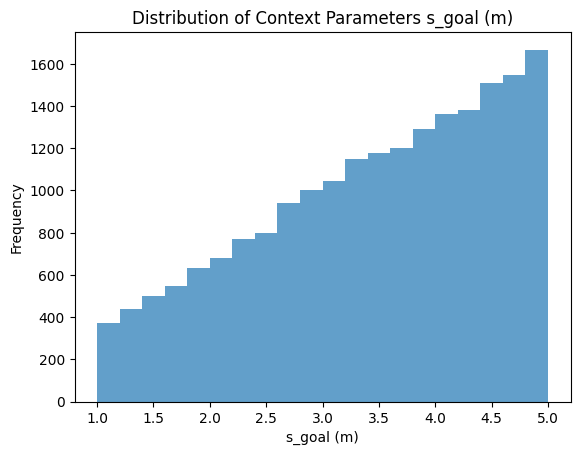

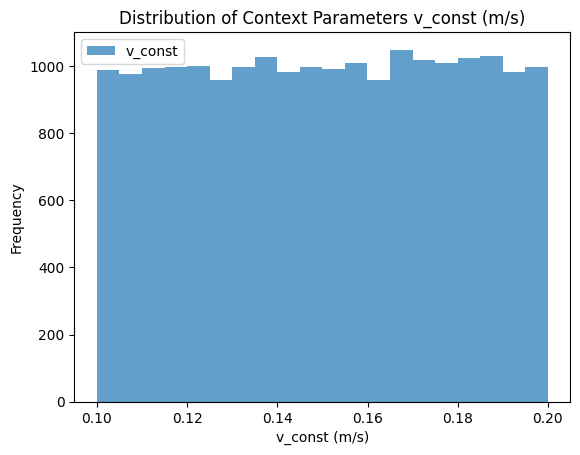

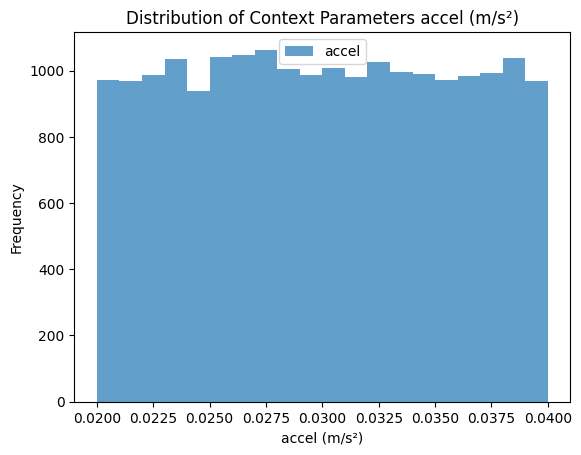

In [15]:
# plot histogram for s_goal, v_const, and accel in dataGenerator.sample_contexts to visualize

import matplotlib.pyplot as plt
s_goals = [np.linalg.norm(ctx.s_goal) for ctx in dataGenerator.sample_contexts]
plt.hist(s_goals, bins=20, alpha=0.7, label='s_goal')
plt.title("Distribution of Context Parameters s_goal (m)")
plt.xlabel("s_goal (m)")
plt.ylabel("Frequency")
plt.show()

v_consts = [ctx.v_const for ctx in dataGenerator.sample_contexts]
plt.hist(v_consts, bins=20, alpha=0.7, label='v_const')
plt.legend()
plt.title("Distribution of Context Parameters v_const (m/s)")
plt.xlabel("v_const (m/s)")
plt.ylabel("Frequency")
plt.show()

accels = [ctx.a for ctx in dataGenerator.sample_contexts]
plt.hist(accels, bins=20, alpha=0.7, label='accel')
plt.legend()
plt.title("Distribution of Context Parameters accel (m/s²)")
plt.xlabel("accel (m/s²)")
plt.ylabel("Frequency")
plt.show()


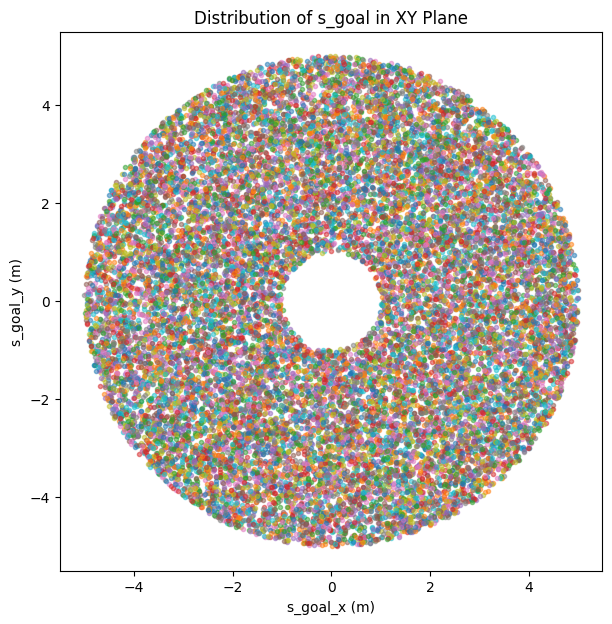

In [16]:
# from sample contexts, plot s_goal_x and s_goal_y in 2d scatter plot to visualize the distribution

fig = plt.figure(figsize=(7, 7))
for ctx in dataGenerator.sample_contexts:
    plt.scatter(ctx.s_goal[0], ctx.s_goal[1], alpha=0.5, marker='.')
plt.xlabel('s_goal_x (m)')
plt.ylabel('s_goal_y (m)')
plt.title("Distribution of s_goal in XY Plane")
plt.show()

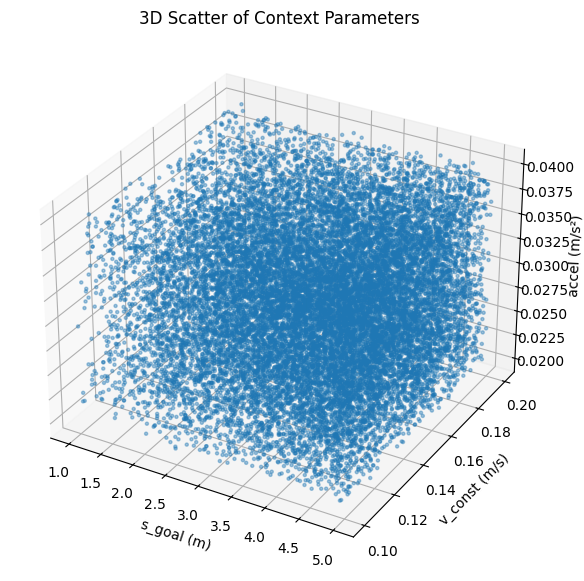

In [17]:
# for each context, plot the s_goal, v_const, and accel distributions in 3 axis scatter plot
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
s_goals = [np.linalg.norm(ctx.s_goal) for ctx in dataGenerator.sample_contexts]
v_consts = [ctx.v_const for ctx in dataGenerator.sample_contexts]
accels = [ctx.a for ctx in dataGenerator.sample_contexts]
ax.scatter(s_goals, v_consts, accels, alpha=0.4, marker='.')
ax.set_xlabel('s_goal (m)')
ax.set_ylabel('v_const (m/s)')
ax.set_zlabel('accel (m/s²)')
plt.title("3D Scatter of Context Parameters")
plt.show()

In [12]:
'''
# for each row of sample point, reshape the trajectory columns back to (50, 3)
# 1. Isolate only the trajectory columns (the last 150 columns)
trajectory_data = df.filter(like='pos_').to_numpy()

# 2. Reshape from (N, 150) to (N, 50, 3)
# N is automatically determined by -1
n_samples = trajectory_data.shape[0]
traject_dataset = trajectory_data.reshape(n_samples, 50, 3)
'''
traject_dataset = np.array(dataset['targets'].tolist()) # Shape: (N, 50, 3)

print(f"Dataset Shape: {traject_dataset.shape}")
# Result: (N, 50, 3)

print("Example Trajectory :")
print(traject_dataset[0: 10])

Dataset Shape: (1000000, 50, 7)
Example Trajectory :
[[[-1.38574219  0.05126953  0.         ...  0.          0.
    1.        ]
  [-1.38964844  0.05142212  0.         ...  0.          0.
    1.        ]
  [-1.39453125  0.05160522  0.         ...  0.          0.
    1.        ]
  ...
  [-1.54980469  0.05734253  0.         ...  0.          0.
    1.        ]
  [-1.55175781  0.05743408  0.         ...  0.          0.
    1.        ]
  [-1.5546875   0.05752563  0.         ...  0.          0.
    1.        ]]

 [[-0.72265625  0.0267334   0.         ...  0.          0.
    1.        ]
  [-0.72851562  0.02696228  0.         ...  0.          0.
    1.        ]
  [-0.734375    0.0271759   0.         ...  0.          0.
    1.        ]
  ...
  [-1.00292969  0.03710938  0.         ...  0.          0.
    1.        ]
  [-1.00878906  0.037323    0.         ...  0.          0.
    1.        ]
  [-1.01464844  0.03753662  0.         ...  0.          0.
    1.        ]]

 [[-1.05175781  0.03890991  0. 

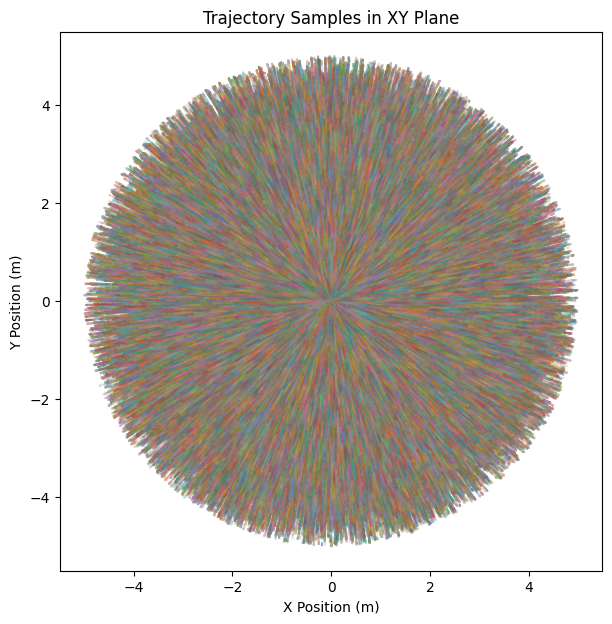

In [19]:

# for each trajectory, plot trajectory points in xy spatial plane # one trajectory for one color
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111)
for traj in traject_dataset:
    ax.plot(traj[:, 0], traj[:, 1], alpha=0.2, marker='.', markersize=0.01)  # Plot x vs y
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
plt.title("Trajectory Samples in XY Plane")
plt.show()


t_init values shape: (1000000,)


100%|██████████| 10000/10000 [00:06<00:00, 1510.93it/s]


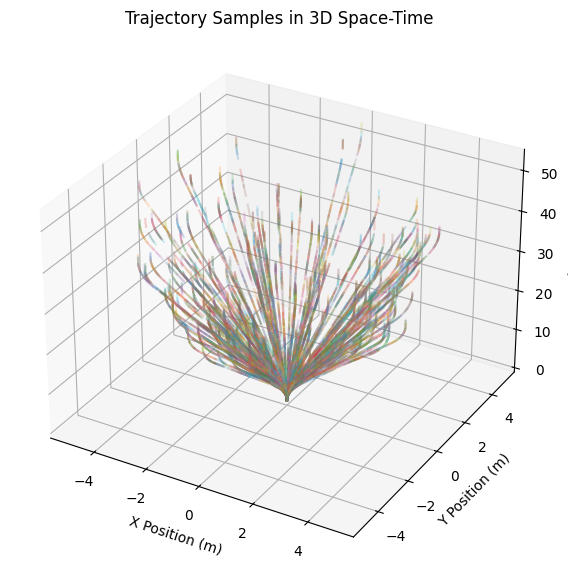

In [16]:
import matplotlib.pyplot as plt

# corresponding t_init for each index
t_init_values = df['t_init'].values
print("t_init values shape:", t_init_values.shape)

# plot each trajectory data in 3d plot, where z-axis is t of the trajectory point, and xy is the spatial 2d position
# so calculate the t values for each trajectory point based on t_init and the time step dt = traject_gen.dt
dt = 1.0 / 25
t_values = t_init_values[:, np.newaxis] + np.arange(50) * dt
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')
for traj, t_vals in tqdm(zip(traject_dataset[:10000], t_values[:10000]), total=10000):
    ax.plot(traj[:, 0], traj[:, 1], t_vals, alpha=0.2, marker='.', markersize=0.01)  # Plot x vs y vs t
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_zlabel('Time (s)')
plt.title("Trajectory Samples in 3D Space-Time")
plt.show()




This is for fun

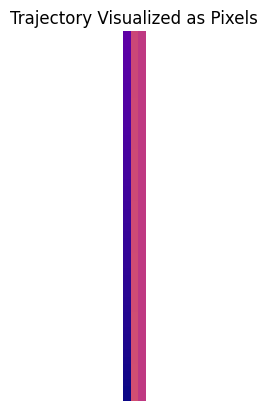

In [ ]:
# this function takes in a trajectory of shape (50, 3) and visualizes it as 50 * 3 pixels in a 2d image
# the 3 pixels each represent the x, y, z position as color in plasma color scale
def plot_traject_as_pix(traject) :
    #min_val = -6
    #max_val = 6
    min_val = np.min(traject)
    max_val = np.max(traject)
    # Normalize the trajectory data to [0, 1] for color mapping
    norm_traj = (traject - min_val) / (max_val - min_val)
    # Create an image of shape (50, 3, 3) where the last dimension is RGB
    img = np.zeros((50, 3, 3))
    for i in range(50):
        for j in range(3):
            # Map the normalized value to a color (using a simple colormap)
            color_val = norm_traj[i, j]
            img[i, j] = plt.cm.plasma(color_val)[:3]  # Get RGB from plasma colormap
    plt.imshow(img)
    plt.title("Trajectory Visualized as Pixels")
    plt.axis('off')

# Example usage
plot_traject_as_pix(traject_dataset[182])

